In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from lincs_gsnn.data.DXDTDataset import DXDTDataset
from torch.utils.data import DataLoader 

from matplotlib import pyplot as plt
from sklearn.metrics import r2_score
from lincs_gsnn.models.ODEFunc import ODEFunc
from lincs_gsnn.models.ODEWrapper import ODEWrapper
from lincs_gsnn.data.TrajDataset import TrajDataset
from lincs_gsnn.data.DXDTDataset import DXDTDataset

from gsnn.interpret.utils import plot_edge_importance, plot_node_importance

import networkx as nx

import seaborn as sbn
import gseapy as gp

%load_ext autoreload
%autoreload 2


/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/pypath/inputs/ramp/_rest.py:54: UserWarning: Failed to load RaMP ID types.
  warnings.warn(msg)


# Trametinib (MEK inhibitor) – MAPK-addicted vs MAPK-independent context: 


If trametinib (MEK1/2 inhibitor) causes significant suppression of ERK-dependent genes – for example, downregulating the feedback regulator DUSP6 – in RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20), which have hyperactive MAPK signaling and are very sensitive to MEK inhibition, but produces little change in those same genes in PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition), due to the latter’s proliferation being driven by alternate pathways (e.g. PI3K/ER signaling rather than MAPK), then MyModel should predict that DUSP6 (and other ERK-target genes) drop in MDA-MB-231/BT-20 but remain relatively unchanged in MCF7/T47D. The model’s contrastive explanation should implicate the RAS–RAF–MEK–ERK cascade as the differentiating factor – for instance, highlighting mutant KRAS/BRAF or downstream ERK activity as the mediator for gene suppression in the RAS-driven cells (In essence, the explanation would show that trametinib’s effect on gene expression is contingent on MAPK pathway addiction, consistent with literature reports that trametinib downregulates ERK-feedback genes like DUSP6 in KRAS-driven cancers).

In [2]:
root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_hi_conf_network_01'
#root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included'
#root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_included_02'
#root = '/home/teddy/local/workflow_outputs/lincs-gsnn/all_edges_no_mirna_01'

cres = pd.read_csv(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_cres.csv')
out_dict = torch.load(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_out_dict.pt')

data = torch.load(os.path.join(root, 'bionetwork/bionetwork.pt'), weights_only=False)

/tmp/ipykernel_32000/2305140939.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  out_dict = torch.load(f'{root}/contrastive_explanation_trametinib_mapk/aggregated_out_dic

# Double check: Do all edges in data show up in `cres`?


In [3]:
input_names = np.array(data.node_names_dict['input'])
function_names = np.array(data.node_names_dict['function'])
output_names = np.array(data.node_names_dict['output'])

src1,dst1 = data.edge_index_dict['input', 'to', 'function'].numpy() 
src2,dst2 = data.edge_index_dict['function', 'to', 'output'].numpy() 
src3,dst3 = data.edge_index_dict['function', 'to', 'function'].numpy() 

src_names = np.concatenate([input_names[src1], function_names[src2], function_names[src3]])
dst_names = np.concatenate([function_names[dst1], output_names[dst2], function_names[dst3]])

edges_from_data = set([(i,j) for i,j in zip(src_names, dst_names)])
edges_from_cres = set([(i,j) for i,j in cres.reset_index()[['source', 'target']].values.tolist()])

diff = edges_from_cres -edges_from_data

# GSNN adds self edges to the data, which will show up in explanations.
assert np.all([i == j for i,j in diff]), 'THERE ARE EDGES IN cres THAT ARE NOT IN data (and are not self edges)'

# Plot the trajectory diffference between the two cell lines of interest

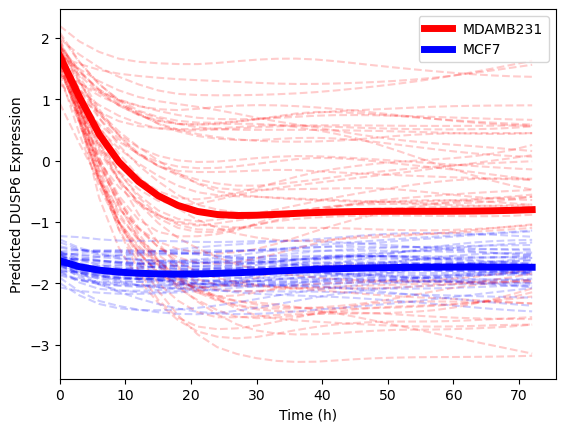

In [4]:
alpha = 0.2
linewidth = 5


gsnn_trajs_x1 = [] 
gsnn_trajs_x2 = [] 
for sample_id, sample_dict in out_dict.items():

    gsnn_trajs_x1.append(sample_dict['xt_hat_1'][:, sample_dict['target_gene_output_ix']])
    gsnn_trajs_x2.append(sample_dict['xt_hat_2'][:, sample_dict['target_gene_output_ix']])

gsnn_trajs_x1 = np.stack(gsnn_trajs_x1, axis=0) 
gsnn_trajs_x2 = np.stack(gsnn_trajs_x2, axis=0) 

plt.figure() 
for i in range(gsnn_trajs_x1.shape[0]):
    plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x1[i], 'r--', alpha=alpha)
    plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x2[i], 'b--', alpha=alpha)

plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x1.mean(axis=0), 'r-', linewidth=linewidth, label=out_dict['sample_0']['cell_line_1']) # make dark red 
plt.plot(out_dict['sample_0']['t'], gsnn_trajs_x2.mean(axis=0), 'b-', linewidth=linewidth, label=out_dict['sample_0']['cell_line_2'])

plt.xlabel('Time (h)')
plt.ylabel(f'Predicted {out_dict["sample_0"]["target_gene"].split("__")[1]} Expression')
plt.legend()

plt.xlim(0)

plt.savefig(f'/mnt/c/Users/natha/Documents/lincs_manu_figures/trametinib_mapk_traj_diff_{out_dict["sample_0"]["cell_line_1"]}_{out_dict["sample_0"]["cell_line_2"]}_{out_dict["sample_0"]["target_gene"]}.png', dpi=300)    
plt.show()




In [5]:
#cres = cres.fillna(0) 
cres_gsnn = cres[['source', 'target'] + [f'gsnn_score_sample_{i}' for i in range(50)]].fillna(0)
cres_gsnn = cres_gsnn.set_index(['source', 'target'])
cres_gsnn = cres_gsnn.assign(mean_gsnn_score = cres_gsnn.values.mean(axis=1))
cres_gsnn = cres_gsnn.assign(std_gsnn_score = cres_gsnn.values.std(axis=1))
cres_gsnn = cres_gsnn.assign(prob_gsnn_score = (cres_gsnn.values > 0.5).mean(axis=1))
cres_gsnn = cres_gsnn[['mean_gsnn_score', 'std_gsnn_score', 'prob_gsnn_score']]

cres_ig = cres[['source', 'target'] + [f'ig_score_sample_{i}' for i in range(50)]].fillna(0)
cres_ig = cres_ig.set_index(['source', 'target'])
cres_ig = cres_ig.assign(mean_ig_score = cres_ig.values.mean(axis=1))
cres_ig = cres_ig.assign(std_ig_score = cres_ig.values.std(axis=1))
cres_ig = cres_ig.assign(prob_pos_ig_score = (cres_ig.values > 0.).mean(axis=1))
cres_ig = cres_ig.assign(prob_neg_ig_score = (cres_ig.values < 0.).mean(axis=1))
cres_ig = cres_ig[['mean_ig_score', 'std_ig_score', 'prob_pos_ig_score', 'prob_neg_ig_score']]

cres_oc = cres[['source', 'target'] + [f'occlusion_score_sample_{i}' for i in range(50)]].fillna(0)
cres_oc = cres_oc.set_index(['source', 'target'])
cres_oc = cres_oc.assign(mean_oc_score = cres_oc.values.mean(axis=1))
cres_oc = cres_oc.assign(std_oc_score = cres_oc.values.std(axis=1))
cres_oc = cres_oc.assign(prob_pos_oc_score = (cres_oc.values > 0.).mean(axis=1))
cres_oc = cres_oc.assign(prob_neg_oc_score = (cres_oc.values < 0.).mean(axis=1))    
cres_oc = cres_oc[['mean_oc_score', 'std_oc_score', 'prob_pos_oc_score', 'prob_neg_oc_score']]

cres_agg = cres_gsnn.merge(cres_ig, on=['source', 'target'], how='inner').merge(cres_oc, on=['source', 'target'], how='inner')
cres_agg = cres_agg.assign(abs_ig_score = lambda x: x.mean_ig_score.abs(),
                           abs_oc_score = lambda x: x.mean_oc_score.abs())

cres_agg.sort_values(by='abs_ig_score', ascending=False).head(100)


,,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
source,target,,,,,,,,,,,,,
RNA__DUSP6,GENE__DUSP6,0.999982,0.000009,0.980769,0.680194,0.274184,1.000000,0.000000,2.526645,0.990929,1.000000,0.000000,0.680194,2.526645
LINE__MCF7,RNA__DUSP6,0.999946,0.000098,0.980769,0.182416,0.121858,0.980769,0.018868,0.245076,0.205130,0.961538,0.037736,0.182416,0.245076
DRUG__BRD-K12343256,PROTEIN__MAP2K1,0.999745,0.000715,0.980769,0.174134,0.131353,0.961538,0.037736,1.438209,0.937871,0.980769,0.018868,0.174134,1.438209
RNA__hsa-miR-181a-5p,RNA__DUSP6,0.999815,0.000321,0.980769,0.172981,0.139411,0.961538,0.037736,0.993499,0.799532,0.961538,0.037736,0.172981,0.993499
PROTEIN__FOXO3,RNA__DUSP6,0.999780,0.000491,0.980769,0.129539,0.110826,0.942308,0.056604,0.592697,0.474709,0.903846,0.094340,0.129539,0.592697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PROTEIN__ABL1,PROTEIN__TP63,0.697617,0.390487,0.730769,0.005123,0.015719,0.480769,0.264151,0.026111,0.073253,0.480769,0.264151,0.005123,0.026111
RNA__CREB1,PROTEIN__CREB1,0.969127,0.134667,0.961538,0.005066,0.024477,0.461538,0.509434,0.026539,0.134263,0.538462,0.433962,0.005066,0.026539
LINE__MDAMB231,RNA__EGR1,0.859680,0.313221,0.846154,0.004994,0.010370,0.653846,0.207547,0.017607,0.034720,0.673077,0.188679,0.004994,0.017607


# Rank nodes by importance (node scores - ContrastiveGSNNExplainer)

In [6]:
cres_node1 = pd.read_csv(f'{root}/contrastive_explanation_trametinib_mapk_node_target/aggregated_cres.csv')

cres_node1 = cres_node1[['node'] + [f'gsnn_score_sample_{i}' for i in range(50)]].fillna(0)
cres_node1 = cres_node1.set_index(['node'])
cres_node1 = cres_node1.assign(mean_gsnn_score = cres_node1.values.mean(axis=1))
cres_node1 = cres_node1.assign(std_gsnn_score = cres_node1.values.std(axis=1))
cres_node1 = cres_node1.assign(prob_gsnn_score = (cres_node1.values > 0.5).mean(axis=1))
cres_node1 = cres_node1[['mean_gsnn_score', 'std_gsnn_score', 'prob_gsnn_score']]
cres_node1 = cres_node1.reset_index().sort_values(by='mean_gsnn_score', ascending=False).assign(gsnn_score_rank = np.arange(len(cres_node1)) + 1)

In [7]:
cres_node2 = pd.read_csv(f'{root}/contrastive_explanation_trametinib_mapk_node_target/aggregated_cres.csv')

cres_node2 = cres_node2[['node'] + [f'ig_score_sample_{i}' for i in range(50)]].fillna(0)
cres_node2 = cres_node2.set_index(['node'])
cres_node2 = cres_node2.assign(mean_ig_score = cres_node2.values.mean(axis=1))
cres_node2 = cres_node2.assign(std_ig_score = cres_node2.values.std(axis=1))
cres_node2 = cres_node2.assign(prob_ig_score = (cres_node2.values > 0.).mean(axis=1))
cres_node2 = cres_node2[['mean_ig_score', 'std_ig_score', 'prob_ig_score']]
cres_node2 = cres_node2.reset_index().sort_values(by='mean_ig_score', ascending=False).assign(ig_score_rank = np.arange(len(cres_node2)) + 1)

In [8]:
cres_node3 = pd.read_csv(f'{root}/contrastive_explanation_trametinib_mapk_node_target/aggregated_cres.csv')

cres_node3 = cres_node3[['node'] + [f'occlusion_score_sample_{i}' for i in range(50)]].fillna(0)
cres_node3 = cres_node3.set_index(['node'])
cres_node3 = cres_node3.assign(mean_oc_score = cres_node3.values.mean(axis=1))
cres_node3 = cres_node3.assign(std_oc_score = cres_node3.values.std(axis=1))
cres_node3 = cres_node3.assign(prob_pos_oc_score = (cres_node3.values > 0.).mean(axis=1))
cres_node3 = cres_node3.assign(prob_neg_oc_score = (cres_node3.values < 0.).mean(axis=1))
cres_node3 = cres_node3[['mean_oc_score', 'std_oc_score', 'prob_pos_oc_score', 'prob_neg_oc_score']]
cres_node3 = cres_node3.reset_index().sort_values(by='mean_oc_score', ascending=False).assign(oc_score_rank = np.arange(len(cres_node3)) + 1)

In [9]:
N = 15

cres_node = cres_node1.merge(cres_node2, on=['node'], how='inner').merge(cres_node3, on=['node'], how='inner')
cres_node = cres_node.sort_values('mean_gsnn_score', ascending=False)

table_out = cres_node.head(N)[['node', 'gsnn_score_rank', 'ig_score_rank', 'oc_score_rank']]
table_out.to_csv(f'/mnt/c/Users/natha/Documents/lincs_manu_figures/trametinib_mapk_node_importance_table.csv', index=False)
table_out

,node,gsnn_score_rank,ig_score_rank,oc_score_rank
0,RNA__DUSP6,1,1,1
1,PROTEIN__ETS1,2,4,5
2,PROTEIN__MAP2K1,3,5,3
3,RNA__hsa-miR-181a-5p,4,2,2
4,PROTEIN__MAPK3,5,8,7
5,PROTEIN__TP53,6,26,41
6,RNA__hsa-miR-125b,7,6,8
7,PROTEIN__MYC,8,17,30
8,PROTEIN__ESR1,9,78,6850
9,PROTEIN__STAT3,10,18,19


# Rank nodes by importance (average of edge scores)

Average the edge scores (mean_gsnn_score) over all edges to/from a given node to create a node importance score. 

Gives an estimate

In [10]:
# sum and product of edge scores 
node_in_sums = cres_agg.reset_index()[['source', 'mean_gsnn_score']].groupby('source').agg(sum_gsnn_score = ('mean_gsnn_score', 'sum'),
                                                                                         prod_gsnn_score = ('mean_gsnn_score', 'prod'))
in_degree = cres_agg.reset_index()[['source', 'target']].groupby('source').count().reset_index()
node_in_sums = node_in_sums.merge(in_degree, on='source', how='left')

node_out_sums = cres_agg.reset_index()[['target', 'mean_gsnn_score']].groupby('target').agg(sum_gsnn_score = ('mean_gsnn_score', 'sum'),
                                                                                         prod_gsnn_score = ('mean_gsnn_score', 'prod'))
out_degree = cres_agg.reset_index()[['source', 'target']].groupby('target').count().reset_index()
node_out_sums = node_out_sums.merge(out_degree, on='target', how='left')

node_in_sums = node_in_sums.rename(columns={'sum_gsnn_score': 'sum_gsnn_in_score', 'prod_gsnn_score': 'prod_gsnn_in_score', 'target': 'degree_in', 'source': 'node'})
node_out_sums = node_out_sums.rename(columns={'sum_gsnn_score': 'sum_gsnn_out_score', 'prod_gsnn_score': 'prod_gsnn_out_score', 'source': 'degree_out', 'target': 'node'})

node_sums = node_in_sums.merge(node_out_sums, on='node', how='left') 
node_sums = node_sums.assign(sum_gsnn_score = lambda x: x.sum_gsnn_in_score + x.sum_gsnn_out_score,
                            degree = lambda x: x.degree_in + x.degree_out,
                            mean2_gsnn_score = lambda x: x.sum_gsnn_score / x.degree, 
                            prod_gsnn_score = lambda x: x.prod_gsnn_in_score * x.prod_gsnn_out_score)

node_sums = node_sums[lambda x: x.node.str.contains('PROTEIN__')]
node_sums = node_sums.sort_values(by='mean2_gsnn_score', ascending=False) # mean2_gsnn_score is the average of all edge scores. 
node_sums = node_sums.assign(rank = lambda x: np.arange(len(x)) + 1)
node_sums.head(5)

,node,sum_gsnn_in_score,prod_gsnn_in_score,degree_in,sum_gsnn_out_score,prod_gsnn_out_score,degree_out,sum_gsnn_score,degree,mean2_gsnn_score,prod_gsnn_score,rank
2021,PROTEIN__FOXO3,6.245371,4.575062e-79,63,28.467492,1.150099e-23,52.0,34.712863,115.0,0.301851,5.261774e-102,1
1910,PROTEIN__EZH2,14.469865,4.406388e-42,56,9.924744,7.544248e-22,28.0,24.394609,84.0,0.290412,3.324288e-63,2
3749,PROTEIN__TCF4,2.373461,1.238368e-19,16,5.990768,2.556603e-20,22.0,8.364230,38.0,0.220111,3.166015e-39,3
2619,PROTEIN__MAP2K1,7.890574,1.926164e-12,20,5.193140,1.387528e-51,40.0,13.083713,60.0,0.218062,2.672606e-63,4
1773,PROTEIN__DUSP22,2.896549,5.822475e-05,8,1.672104,2.082536e-17,13.0,4.568653,21.0,0.217555,1.212552e-21,5


In [11]:
# Expected high importance nodes. 
rel_nodes = ['PROTEIN__MAP2K1', # MEK1
             'PROTEIN__MAP2K2', # MEK2
             'PROTEIN__MAPK1', # ERK1
             'PROTEIN__MAPK3', # ERK2
             'PROTEIN__ETS1', # ETS
             'PROTEIN__ETV1', # ETS
             ]

for n in rel_nodes: 
    if n in node_sums.node.values: 
        print(n, node_sums.loc[node_sums.node == n]['rank'].item(), node_sums.loc[node_sums.node == n]['mean2_gsnn_score'].item())
    else: 
        print(n, 'not in node_sums')


PROTEIN__MAP2K1 4 0.21806189128990003
PROTEIN__MAP2K2 8 0.2083477195954054
PROTEIN__MAPK1 15 0.1646275026200764
PROTEIN__MAPK3 7 0.21247138897769566
PROTEIN__ETS1 76 0.11066804247565916
PROTEIN__ETV1 not in node_sums


# Top edge rankings 

In [12]:
edge_ranks = cres_agg[['mean_gsnn_score']].reset_index().sort_values(by='mean_gsnn_score', ascending=False) 
edge_ranks = edge_ranks[lambda x: ~x.source.str.contains('LINE__')]
edge_ranks = edge_ranks[lambda x: x.source.str.contains('PROTEIN__') & x.target.str.contains('PROTEIN__')]
edge_ranks = edge_ranks.assign(rank = lambda x: np.arange(len(x)) + 1)
edge_ranks.head(10).style.hide() 


source,target,mean_gsnn_score,rank
PROTEIN__TP53,PROTEIN__ETS1,0.987367,1
PROTEIN__MAP2K1,PROTEIN__TAL1,0.975782,2
PROTEIN__MAPK3,PROTEIN__ETS1,0.936367,3
PROTEIN__GSK3B,PROTEIN__ETS1,0.926387,4
PROTEIN__MAP2K1,PROTEIN__GSK3B,0.916040,5
PROTEIN__MAP2K1,PROTEIN__MAPK3,0.911687,6
PROTEIN__MAP2K1,PROTEIN__MAPK1,0.911258,7
PROTEIN__NFE2L2,PROTEIN__ETS1,0.905912,8
PROTEIN__MAPK1,PROTEIN__FOXO3,0.901318,9
PROTEIN__MAPK3,PROTEIN__FOXO3,0.885763,10


In [13]:
edge_ranks = cres_agg[['mean_ig_score']].reset_index().sort_values(by='mean_ig_score', ascending=False) 
edge_ranks = edge_ranks[lambda x: ~x.source.str.contains('LINE__')]
edge_ranks = edge_ranks[lambda x: x.source.str.contains('PROTEIN__') & x.target.str.contains('PROTEIN__')]
edge_ranks = edge_ranks.assign(rank = lambda x: np.arange(len(x)) + 1)
edge_ranks.head(10).style.hide() 

source,target,mean_ig_score,rank
PROTEIN__MAPK3,PROTEIN__FOXO3,0.024830,1
PROTEIN__MAPK1,PROTEIN__FOXO3,0.024807,2
PROTEIN__MAP2K1,PROTEIN__TAL1,0.024615,3
PROTEIN__MAP2K1,PROTEIN__MAPK3,0.016650,4
PROTEIN__MAP2K1,PROTEIN__MAPK1,0.016204,5
PROTEIN__MAP2K2,PROTEIN__MAPK3,0.015689,6
PROTEIN__TP53,PROTEIN__ETS1,0.012995,7
PROTEIN__MAPK3,PROTEIN__ETS1,0.011847,8
PROTEIN__MAP2K1,PROTEIN__GSK3B,0.011042,9
PROTEIN__MAP2K2,PROTEIN__MAPK1,0.009514,10


In [14]:
edge_ranks = cres_agg[['mean_oc_score']].reset_index().sort_values(by='mean_oc_score', ascending=False) 
edge_ranks = edge_ranks[lambda x: ~x.source.str.contains('LINE__')]
edge_ranks = edge_ranks[lambda x: x.source.str.contains('PROTEIN__') & x.target.str.contains('PROTEIN__')]
edge_ranks = edge_ranks.assign(rank = lambda x: np.arange(len(x)) + 1)
edge_ranks.head(10).style.hide() 

source,target,mean_oc_score,rank
PROTEIN__MAP2K1,PROTEIN__TAL1,0.276770,1
PROTEIN__MAP2K1,PROTEIN__MAPK3,0.153637,2
PROTEIN__MAP2K2,PROTEIN__MAPK3,0.121147,3
PROTEIN__MAP2K1,PROTEIN__MAPK1,0.118631,4
PROTEIN__MAP2K1,PROTEIN__GSK3B,0.105408,5
PROTEIN__MAPK3,PROTEIN__FOXO3,0.105017,6
PROTEIN__MAPK1,PROTEIN__FOXO3,0.097084,7
PROTEIN__MAP2K2,PROTEIN__MAPK1,0.092797,8
PROTEIN__MAP2K2,PROTEIN__SMAD4,0.068239,9
PROTEIN__MAPK3,PROTEIN__ETS1,0.055060,10


# Relevant Path Rankings 

In [15]:
G = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph(), edge_attr='mean_gsnn_score')

shortest_paths = list( nx.all_simple_paths(G, source='DRUG__BRD-K12343256', target='RNA__DUSP6', cutoff=6))

path_df = {'path': [], 'score_product': [], 'score_sum': [], 'score_mean': [], 'path_length': []}
for p in shortest_paths: 

    score_product = 1 
    score_sum = 0 
    for ii in range(len(p) - 1): 
        score_product *= G[p[ii]][p[ii+1]]['mean_gsnn_score']
        score_sum += G[p[ii]][p[ii+1]]['mean_gsnn_score']

    path_df['path'].append(p)
    path_df['score_product'].append(score_product)
    path_df['score_sum'].append(score_sum)
    path_df['score_mean'].append(score_sum / (len(p) - 1))
    path_df['path_length'].append(len(p))

path_df = pd.DataFrame(path_df)
path_df = path_df.sort_values(by='score_mean', ascending=False).reset_index(drop=True)

In [26]:
TOP_N_PATHS = 10 
SORT_BY = 'score_product'

path_df = path_df.assign(path_short = [' -> '.join(p[1:-1]) for p in path_df.path.values])
path_df = path_df.sort_values(by=SORT_BY, ascending=False).reset_index(drop=True)
path_df = path_df.assign(**{SORT_BY: np.round(path_df[SORT_BY].values, 3)})
path_df_out = path_df.head(TOP_N_PATHS)[['path_short', 'path_length', SORT_BY]]
path_df_out.to_csv(f'/mnt/c/Users/natha/Documents/lincs_manu_figures/trametinib_mapk_path_importance_table.csv', index=False)
path_df_out


,path_short,path_length,score_product
0,PROTEIN__MAP2K1 -> PROTEIN__TAL1 -> RNA__hsa-m...,5,0.891
1,PROTEIN__MAP2K1 -> PROTEIN__MAPK3 -> PROTEIN__...,5,0.853
2,PROTEIN__MAP2K1 -> PROTEIN__GSK3B -> PROTEIN__...,5,0.848
3,PROTEIN__MAP2K1 -> PROTEIN__MAPK1 -> PROTEIN__...,5,0.821
4,PROTEIN__MAP2K1 -> PROTEIN__MAPK3 -> PROTEIN__...,5,0.807
5,PROTEIN__MAP2K2 -> PROTEIN__MAPK3 -> PROTEIN__...,5,0.786
6,PROTEIN__MAP2K2 -> PROTEIN__MAPK3 -> PROTEIN__...,5,0.744
7,PROTEIN__MAP2K2 -> PROTEIN__SMAD4 -> RNA__hsa-...,5,0.700
8,PROTEIN__MAP2K1 -> PROTEIN__MAPK3 -> PROTEIN__...,6,0.681
9,PROTEIN__MAP2K2 -> PROTEIN__MAPK1 -> PROTEIN__...,5,0.679


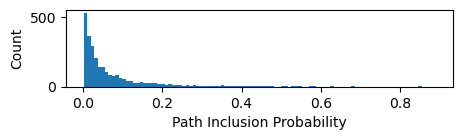

In [14]:
plt.figure(figsize=(5,1))
plt.hist(path_df.score_product.values, bins=100)
plt.xlabel('Path Inclusion Probability')
plt.ylabel('Count')
plt.show()


# Comparing Node Importance with random walks 

Naive model: all edges have equal transition probability (base network)  
Our model: edge transition probability is based on interpretation scores (ContrastiveGSNNExplainer)

Using a RW on the network with edge probabilities provides the number of times node is visited, and quantifies both general network geometries and the learned edge importance probabilities. Quantifying the difference (tstat or ratio) between the naive (equal transition probs.) and our importance scores, should give an estimate of how much MORE likely our learned model is to visiting/using a node. 

This is intended to evaluate node importances in a way that takes the network geometry into account. 

In [184]:
def random_walk(G, source, steps=100, restarts=100, edge_attr=None):
    """
    Perform random walks starting from source node, traversing forward along directed edges.
    
    Parameters
    ----------
    G : nx.DiGraph
        Directed graph to walk on (edges go from source -> target)
    source : node
        Starting node for each walk
    steps : int
        Number of steps per walk
    restarts : int
        Number of independent walks to perform
    edge_attr : str, optional
        Edge attribute to use as transition weights. Weights are normalized
        to probabilities per node. If None, uniform random over outgoing edges.
    
    Returns
    -------
    dict
        Dictionary mapping node -> probability of reaching that node
        (fraction of walks that visited the node at least once)
    """
    from collections import defaultdict
    import random
    
    # Track whether each node was visited in each restart
    visited_per_restart = defaultdict(set)  # node -> set of restart indices where visited
    
    # Precompute outgoing neighbors and normalized transition probabilities
    neighbors_cache = {}
    probs_cache = {}
    
    for node in G.nodes():
        # Get outgoing neighbors (nodes reachable via edges FROM this node)
        out_neighbors = list(G.successors(node))
        neighbors_cache[node] = out_neighbors
        
        if edge_attr and out_neighbors:
            # Get edge weights for outgoing edges: node -> neighbor
            weights = []
            for nbr in out_neighbors:
                w = G.edges[node, nbr].get(edge_attr, 1.0)
                weights.append(max(w, 0.0))  # Ensure non-negative
            
            # Normalize to probabilities
            total = sum(weights)
            if total > 0:
                probs_cache[node] = [w / total for w in weights]
            else:
                # Fallback to uniform if all weights are zero
                probs_cache[node] = [1.0 / len(out_neighbors)] * len(out_neighbors)
    
    for r in range(restarts):
        current = source
        visited_per_restart[current].add(r)
        
        for _ in range(steps):
            out_neighbors = neighbors_cache[current]
            if not out_neighbors:  # Dead end (no outgoing edges) - restart
                current = source
            elif edge_attr:
                current = random.choices(out_neighbors, weights=probs_cache[current])[0]
            else:
                current = random.choice(out_neighbors)
            visited_per_restart[current].add(r)
    
    # Convert to probability: fraction of restarts that visited each node
    reach_prob = {node: len(restart_set) / restarts 
                  for node, restart_set in visited_per_restart.items()}
    
    return reach_prob


def get_ratio(x, y, eps=1e-10): 
    return (np.mean(x) / (np.mean(y) + eps))

def get_tstat(x, y, eps=1e-10): 
    return (np.mean(x) - np.mean(y)) / np.sqrt(np.var(x) / len(x) + np.var(y) / len(y) + eps)

from scipy.stats import mannwhitneyu
def get_pval(x, y):  
    ''' use mann whitney u test to get pval '''
    return mannwhitneyu(x, y).pvalue


In [185]:
N_STEPS = 10
N_RESTARTS = 100000

#G_model = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph(), edge_attr='mean_gsnn_score')
G_naive = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph(), edge_attr=None)

#res_model = random_walk(G_model, 'DRUG__BRD-K12343256', steps=N_STEPS, restarts=N_RESTARTS, edge_attr='mean_gsnn_score')
res_naive = random_walk(G_naive, 'DRUG__BRD-K12343256', steps=N_STEPS, restarts=N_RESTARTS)

#res_model2 = random_walk(G_model.reverse(copy=True), 'RNA__DUSP6', steps=N_STEPS, restarts=N_RESTARTS, edge_attr='mean_gsnn_score')
G_naive_rev = G_naive.reverse(copy=True)
res_naive2 = random_walk(G_naive_rev, 'GENE__DUSP6', steps=N_STEPS, restarts=N_RESTARTS)

In [186]:
node_rw = cres_node[['node', 'mean_gsnn_score']].assign(rw_from_trametinib = lambda x: [res_naive[n] if n in res_naive else 0 for n in x.node.values])
node_rw = node_rw.assign(rw_from_dusp6 = lambda x: [res_naive2[n] if n in res_naive2 else 0 for n in x.node.values])
node_rw = node_rw[lambda x: (x.rw_from_trametinib > 0) & (x.rw_from_dusp6 > 0)]

node_rw = node_rw.assign(rw_from_trametinib_log10 = lambda x: np.log10(x.rw_from_trametinib),
                         rw_from_dusp6_log10 = lambda x: np.log10(x.rw_from_dusp6))

node_rw = node_rw.assign(rw_from_trametinib_log10_zscore = lambda x: (x.rw_from_trametinib_log10 - x.rw_from_trametinib_log10.mean()) / x.rw_from_trametinib_log10.std(),
                        rw_from_dusp6_log10_zscore = lambda x: (x.rw_from_dusp6_log10 - x.rw_from_dusp6_log10.mean()) / x.rw_from_dusp6_log10.std())
node_rw.head()

,node,mean_gsnn_score,rw_from_trametinib,rw_from_dusp6,rw_from_trametinib_log10,rw_from_dusp6_log10,rw_from_trametinib_log10_zscore,rw_from_dusp6_log10_zscore
0,RNA__DUSP6,0.999865,0.00018,1.00000,-3.744727,0.000000,-0.524625,6.032468
1,PROTEIN__ETS1,0.998222,0.00417,0.16210,-2.379864,-0.790217,1.271113,4.920248
2,PROTEIN__MAP2K1,0.998049,0.50000,0.00065,-0.301030,-3.187087,4.006214,1.546685
3,RNA__hsa-miR-181a-5p,0.997800,0.00217,0.15659,-2.663540,-0.805236,0.897883,4.899109
4,PROTEIN__MAPK3,0.996623,0.10967,0.01229,-0.959912,-1.910448,3.139329,3.343537


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     989.8
Date:                Tue, 27 Jan 2026   Prob (F-statistic):          3.43e-318
Time:                        14:02:27   Log-Likelihood:                -3977.8
No. Observations:                2531   AIC:                             7962.
Df Residuals:                    2528   BIC:                             7979.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

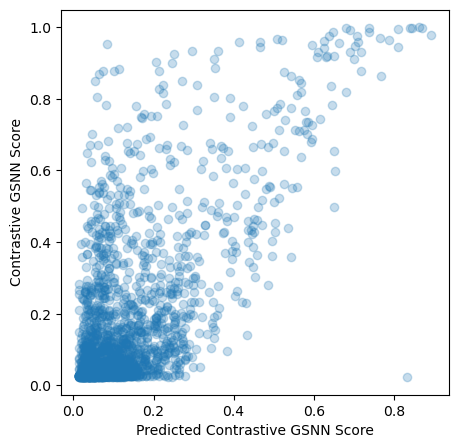

In [214]:
from statsmodels.api import OLS, Logit, add_constant, families
from statsmodels.othermod.betareg import BetaModel
#from statsmodels.miscmodels.generic import BetaModel

X = node_rw[['rw_from_trametinib_log10_zscore', 'rw_from_dusp6_log10_zscore']]
y = node_rw.mean_gsnn_score.values

# logit transform 
y = np.log(y / (1 - y))         # transform to make a OLS appropriate

sigmoid = lambda x: 1 / (1 + np.exp(-x))

model = OLS(y, add_constant(X))
#model = Logit(y, add_constant(X))                                              # Not appropriate for continuous data 
#model = BetaModel(y.ravel(), add_constant(X), link=families.links.logit())     # appropriate but perhaps overcomplicated 
res = model.fit()
print(res.summary())

yhat = res.predict(add_constant(X))

r2 = r2_score(sigmoid(y), sigmoid(yhat))
r = np.corrcoef(sigmoid(yhat), sigmoid(y))[0,1]
print(f'r2: {r2}, r: {r}')

plt.figure(figsize=(5,5))
plt.scatter(sigmoid(yhat), sigmoid(y), alpha=0.25)
plt.xlabel('Predicted Contrastive GSNN Score')
plt.ylabel('Contrastive GSNN Score')
plt.show()



In [188]:
node_rw = node_rw.assign(yhat = lambda x: res.predict(add_constant(x[['rw_from_trametinib_log10_zscore', 'rw_from_dusp6_log10_zscore']]))) 
node_rw = node_rw.assign(error = lambda x: (x.mean_gsnn_score - x.yhat)**2)
node_rw.sort_values(by='error', ascending=False).head(5)

,node,mean_gsnn_score,rw_from_trametinib,rw_from_dusp6,rw_from_trametinib_log10,rw_from_dusp6_log10,rw_from_trametinib_log10_zscore,rw_from_dusp6_log10_zscore,yhat,error
22,RNA__CREB1,0.953403,0.00074,0.00004,-3.130768,-4.397940,0.283155,-0.157575,0.117653,0.698478
55,RNA__CSNK2A2,0.848702,0.00002,0.00013,-4.698970,-3.886057,-1.780112,0.562894,0.059868,0.622260
47,RNA__EGR1,0.877372,0.00072,0.00003,-3.142668,-4.522879,0.267500,-0.333425,0.105780,0.595355
50,RNA__FOS,0.868245,0.00235,0.00001,-2.628932,-5.000000,0.943416,-1.004967,0.102785,0.585929
48,RNA__CDK2,0.877076,0.00105,0.00005,-2.978811,-4.301030,0.483085,-0.021176,0.140226,0.542948


# Edge score distribution

# edges > 0.5 mean gsnn score 673
total # edges 107317


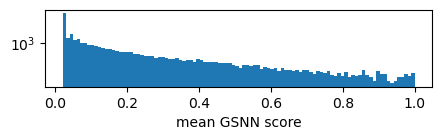

In [ ]:
print('# edges > 0.5 mean gsnn score', len(cres_agg[cres_agg.mean_gsnn_score > 0.5]))
print('total # edges', len(cres_agg))

plt.figure(figsize=(5,1))
plt.hist(cres_agg.mean_gsnn_score.values, bins=100)
plt.yscale('log')
plt.xlabel('mean GSNN score')
plt.show()

# Most import contextual edges (LINE__)

In [22]:
cres_agg.reset_index()[lambda x: (x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))].sort_values(by='mean_gsnn_score', ascending=False).head(10)

,source,target,mean_gsnn_score,std_gsnn_score,prob_gsnn_score,mean_ig_score,std_ig_score,prob_pos_ig_score,prob_neg_ig_score,mean_oc_score,std_oc_score,prob_pos_oc_score,prob_neg_oc_score,abs_ig_score,abs_oc_score
350,LINE__MCF7,RNA__DUSP6,0.999946,0.000098,0.980769,0.182416,0.121858,0.980769,0.018868,0.245076,0.205130,0.961538,0.037736,0.182416,0.245076
1907,LINE__MDAMB231,RNA__DUSP6,0.999869,0.000202,0.980769,0.006721,0.142344,0.557692,0.433962,-0.021315,0.318018,0.480769,0.509434,0.006721,0.021315
3029,LINE__MDAMB231,RNA__hsa-miR-101*,0.998974,0.002570,0.980769,-0.013675,0.090233,0.538462,0.452830,-0.032966,0.191525,0.519231,0.471698,0.013675,0.032966
1549,LINE__MCF7,RNA__hsa-miR-101*,0.982390,0.110194,0.961538,0.041563,0.050229,0.865385,0.113208,0.082192,0.102553,0.846154,0.132075,0.041563,0.082192
3101,LINE__MDAMB231,RNA__hsa-miR-181a-5p,0.978664,0.133950,0.961538,-0.006804,0.049040,0.500000,0.471698,-0.017402,0.089135,0.480769,0.490566,0.006804,0.017402
1622,LINE__MCF7,RNA__hsa-miR-181a-5p,0.978331,0.132817,0.961538,0.015018,0.032411,0.692308,0.283019,0.036055,0.051164,0.769231,0.207547,0.015018,0.036055
3050,LINE__MDAMB231,RNA__hsa-miR-125b,0.976901,0.124254,0.961538,-0.002551,0.022763,0.500000,0.471698,-0.002919,0.049841,0.423077,0.547170,0.002551,0.002919
1889,LINE__MDAMB231,RNA__CREB1,0.969495,0.086530,0.980769,-0.007721,0.019514,0.403846,0.584906,-0.008348,0.081924,0.500000,0.490566,0.007721,0.008348
2313,LINE__MDAMB231,PROTEIN__FOXO3,0.967942,0.140756,0.961538,0.000672,0.020242,0.557692,0.415094,0.000879,0.041707,0.500000,0.471698,0.000672,0.000879
1570,LINE__MCF7,RNA__hsa-miR-125b,0.960620,0.146421,0.942308,0.003450,0.023184,0.538462,0.415094,0.005946,0.035167,0.519231,0.433962,0.003450,0.005946


# Highest out-going edge scores from MEK1/2

In [93]:
cres_agg.reset_index()[lambda x: (x.source == 'PROTEIN__MAPK1')].sort_values(by='mean_gsnn_score', ascending=False).head(5)[['source', 'target']]

,source,target
9673,PROTEIN__MAPK1,PROTEIN__FOXO3
9733,PROTEIN__MAPK1,PROTEIN__RPS6KA5
9705,PROTEIN__MAPK1,PROTEIN__MYCN
9715,PROTEIN__MAPK1,PROTEIN__POU5F1
9757,PROTEIN__MAPK1,PROTEIN__TWIST1


In [94]:
cres_agg.reset_index()[lambda x: (x.source == 'PROTEIN__MAPK3')].sort_values(by='mean_gsnn_score', ascending=False).head(5)[['source', 'target']]

,source,target
10015,PROTEIN__MAPK3,PROTEIN__ETS1
10021,PROTEIN__MAPK3,PROTEIN__FOXO3
10005,PROTEIN__MAPK3,PROTEIN__E2F4
9997,PROTEIN__MAPK3,PROTEIN__CEBPA
10084,PROTEIN__MAPK3,PROTEIN__SOX2


---
# Subgraph Explanation Plot 
---

In [109]:
TARGET_GENE = 'GENE__DUSP6' #'RNA__DUSP6' #'GENE__DUSP6' # 'RNA_DUSP6' if removing GENES___

FILTER_TO_DRUG = False
DRUG_NAME = 'DRUG__BRD-K12343256'


TOP_N_NODES = 100
REMOVE_CELL___EDGES = True
REMOVE_GENE___EDGES = False
PROB_FILTER_THRESH = 0.5

CLIP_SCORE = True
CLIP_VALUE = 0.33

SCALE_SCORE = True
MIN_SCORE = -1
MAX_SCORE = 1

COLOR_BY_SCORE = 'mean_oc_score' # options: 'mean_ig_score', 'mean_oc_score', 'mean_gsnn_score'

FIGSIZE = (13,11)
INTERACTIVE = False

✅ Saved figure to /mnt/c/Users/natha/Documents/lincs_manu_figures/explanation_subgraph_plot_non_interactive.png


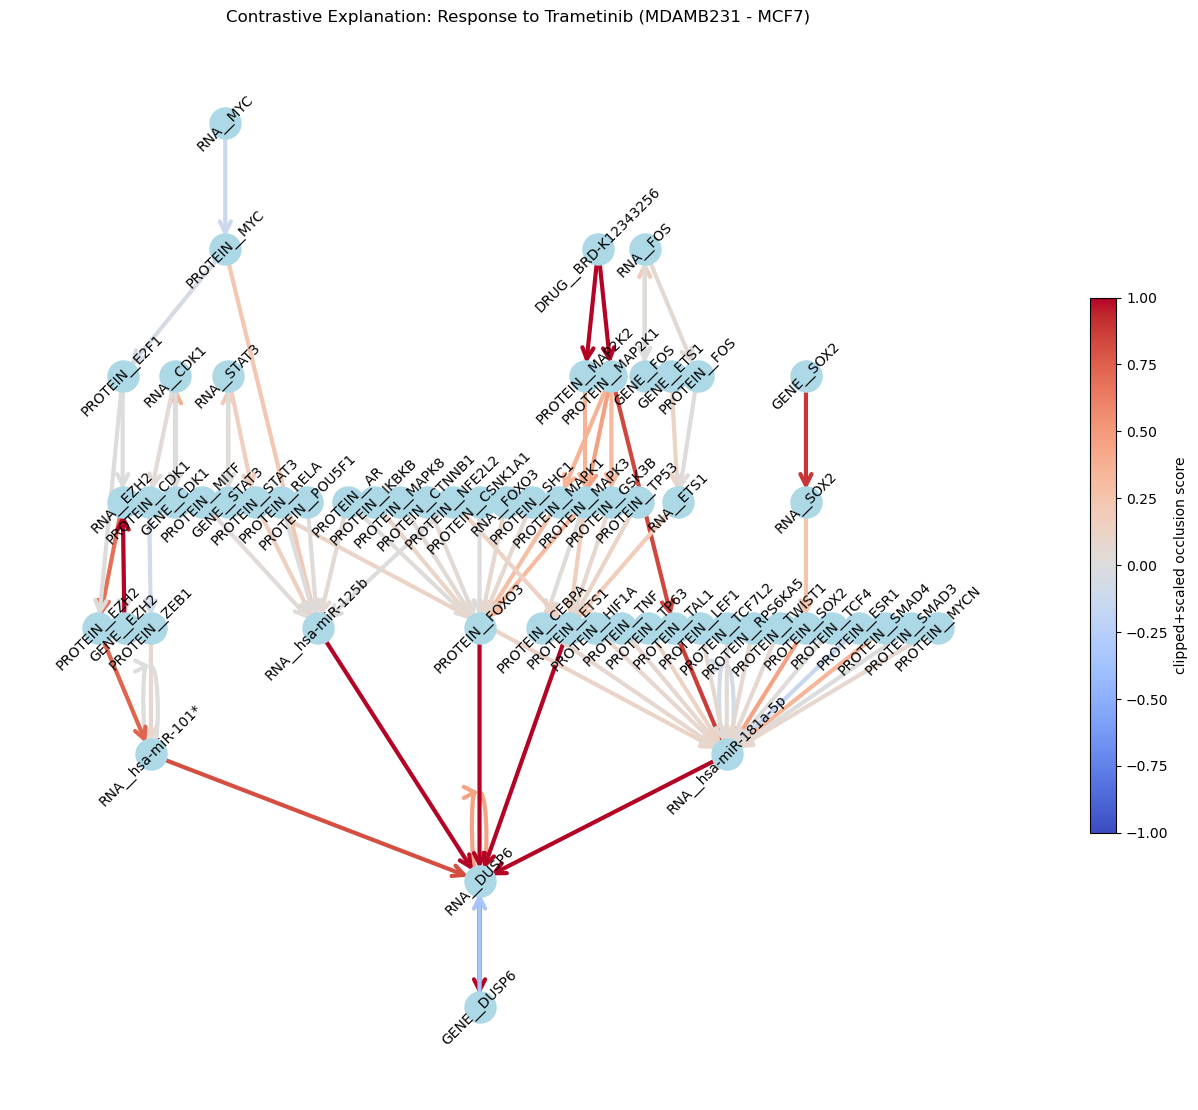

In [111]:
ccres = cres_agg.reset_index().rename(columns={COLOR_BY_SCORE: 'score'})[['source', 'target', 'score', 'mean_gsnn_score']]

if REMOVE_CELL___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))]

if REMOVE_GENE___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('GENE__') | x.target.str.contains('GENE__'))]

ccres = ccres[ccres.mean_gsnn_score > PROB_FILTER_THRESH]

ccres = ccres.sort_values(by='mean_gsnn_score', ascending=False).head(TOP_N_NODES)

# SCALING FOR COLOR DISPLAY
if CLIP_SCORE: 
    ccres = ccres.assign(score = lambda x: x.score.values.clip(-CLIP_VALUE, CLIP_VALUE))

if SCALE_SCORE:
    # Scale by absolute max so 0 stays at 0 and signs are preserved
    abs_max = ccres.score.abs().max()
    ccres.loc[ccres.score < 0, 'score'] = ccres.loc[ccres.score < 0, 'score'] / np.abs(ccres.loc[ccres.score < 0, 'score'].min())
    ccres.loc[ccres.score > 0, 'score'] = ccres.loc[ccres.score > 0, 'score'] / np.abs(ccres.loc[ccres.score > 0, 'score'].max())

if INTERACTIVE: 
    figsize = (10, 10)
else: 
    figsize = FIGSIZE

plot_edge_importance(ccres, 
                     figsize=figsize, 
                     leafs=[TARGET_GENE], 
                     roots=[DRUG_NAME] if FILTER_TO_DRUG else None,
                     title=f'Contrastive Explanation: Response to Trametinib (MDAMB231 - MCF7)',
                     interactive=INTERACTIVE, 
                     save=f'/mnt/c/Users/natha/Documents/lincs_manu_figures/explanation_subgraph_plot_non_interactive.png',
                     dpi=300, 
                     colorbar_label='clipped+scaled occlusion score')

# What regulators do FOXO3 and ETS1 share? 


In [33]:
foxo3_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('PROTEIN__FOXO3')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('PROTEIN__ETS1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(foxo3_regs) & set(ets1_regs)

_ = [print(x) for x in overlap if 'LINE__' not in x]


PROTEIN__MAPK14
PROTEIN__MAPK3


# What regulators do mir181 and ETS1 share? 

In [34]:
mir181_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('hsa-miR-181a-5p')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETS1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(mir181_regs) & set(ets1_regs)
_ = [print(x) for x in overlap if 'LINE__' not in x]

PROTEIN__TAL1
PROTEIN__HIF1A
PROTEIN__SMAD4


# What regulators do MIR181 and FOXO3 share? 

In [35]:
mir181_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('hsa-miR-181a-5p')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
foxo3_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('FOXO3')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(mir181_regs) & set(foxo3_regs)
_ = [print(x) for x in overlap if 'LINE__' not in x]
# What regulators do ETV1 and ETS2 share? 

PROTEIN__CEBPA


# What regulators do ETV1 and ETS1 share? 

In [36]:
etv1_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETV1')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 
ets2_regs = cres_agg.reset_index()[lambda x: x.target.str.contains('ETS2')][['source', 'target', 'mean_gsnn_score']].source.unique().tolist() 

overlap = set(etv1_regs) & set(ets2_regs)
_ = [print(x) for x in overlap if 'LINE__' not in x]

# Number of paths through each regulator

In [37]:
MIN_PATH_LEN = 5 # prior knowledge (check from the paths, for plotting)
CUTOFF = 6 # depth of paths to consider [7 becomes largely intractable]

In [38]:
G = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph())

paths = list(nx.all_simple_paths(G, source='DRUG__BRD-K12343256', target='RNA__DUSP6', cutoff=CUTOFF)) 


6 paths considered
2720 paths found


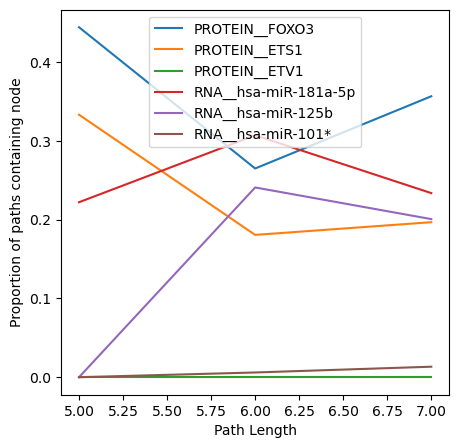

In [39]:
cnt_dict = {i:{'PROTEIN__FOXO3': 0, 
            'PROTEIN__ETS1': 0, 
            'PROTEIN__ETV1': 0, 
            'RNA__hsa-miR-181a-5p': 0, 
            'RNA__hsa-miR-125b': 0,
            'RNA__hsa-miR-101*': 0} for i in range(MIN_PATH_LEN, CUTOFF+2)}

for p in paths: 
    for k in cnt_dict[len(p)]: 
        cnt_dict[len(p)][k] += p.count(k)

print(f'{CUTOFF} paths considered')
print(f'{len(paths)} paths found')

path_len_dict = {i:len([p for p in paths if len(p) == i]) for i in range(MIN_PATH_LEN, CUTOFF+2)}

plt.figure(figsize=(5,5))
for n in cnt_dict[MIN_PATH_LEN]:

    x = [] 
    y = []
    for i in range(MIN_PATH_LEN, CUTOFF+2): 
        x.append(i)
        y.append(cnt_dict[i][n] / path_len_dict[i])
    plt.plot(x, y, label=n)

plt.xlabel('Path Length')
plt.ylabel('Proportion of paths containing node')
plt.legend()
plt.show()



In [40]:
cnt_dict[len(p)]

{'PROTEIN__FOXO3': 908,
 'PROTEIN__ETS1': 501,
 'PROTEIN__ETV1': 0,
 'RNA__hsa-miR-181a-5p': 595,
 'RNA__hsa-miR-125b': 511,
 'RNA__hsa-miR-101*': 34}

---
# What happens to a given cell line drug response trajectory if we remove node X? 
---

In [41]:
def run(root_gsnn, root_traj, sample_id, target_gene, remove_name, cell1, cell2, drug, dose, t=torch.linspace(0, 72, 100)): 

    dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
    obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

    # load data 
    data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)
    model = torch.load(os.path.join(root_gsnn, f'pretrain/pretrained_model_{sample_id}.pt'), weights_only=False)
    dxdt_scale = torch.load(os.path.join(root_gsnn, f'pretrain/dxdt_scale_{sample_id}.pt'), weights_only=False).item()
    x_names = pd.read_csv(os.path.join(root_traj, 'predict_grid/gene_names.csv'))['gene_names'].values.astype(str).tolist()
    dxdt_meta = pd.read_csv(os.path.join(root_traj, 'predict_grid/dxdt_meta.csv'))

    # freeze the model 
    for param in model.parameters():
        param.requires_grad = False
    
    # set model to evaluation mode 
    model = model.eval() 

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = t.to(device)

    target_ix = data.node_names_dict['output'].index(target_gene)       #

    assert drug in dxdt_meta.pert_id.unique(), f'{drug} not found in dxdt_meta'
    assert cell1 in dxdt_meta.cell_iname.unique(), f'{cell1} not found in dxdt_meta'
    assert cell2 in dxdt_meta.cell_iname.unique(), f'{cell2} not found in dxdt_meta'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    cond1 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                        & (dxdt_meta['cell_iname'] == cell1) 
                        & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

    cond2 = dxdt_meta[(dxdt_meta['pert_id'] == drug) 
                        & (dxdt_meta['cell_iname'] == cell2) 
                        & (dxdt_meta['dose'] == dose)].reset_index(drop=True)

    dataset1 = DXDTDataset(meta=cond1, 
                      input_names=data.node_names_dict['input'], 
                      output_names=data.node_names_dict['output'],
                      src_names=x_names,
                      obs_dir=obs_dir,
                      dxdt_dir=dxdt_dir,
                      scale=dxdt_scale)

    dataloader1 = DataLoader(dataset1, batch_size=8, shuffle=False)

    dataset2 = DXDTDataset(meta=cond2, 
                        input_names=data.node_names_dict['input'], 
                        output_names=data.node_names_dict['output'],
                        src_names=x_names,
                        obs_dir=obs_dir,
                        dxdt_dir=dxdt_dir,
                        scale=dxdt_scale)

    dataloader2 = DataLoader(dataset2, batch_size=8, shuffle=False)



    def retrieve_data(dataloader):

        xs = []; ys = [] 
        for i, (x, y) in enumerate(dataloader):
            xs.append(x)
            ys.append(y)
        xs = torch.cat(xs, dim=0)
        ys = torch.cat(ys, dim=0)

        return xs, ys 

    x1, y1 = retrieve_data(dataloader1)
    x2, y2 = retrieve_data(dataloader2)

    x0_1 = x1[[0]] # MDAMB231
    x0_2 = x2[[0]] # MCF7

    ode_gsnn = ODEWrapper(model, 
                        data, 
                        dxdt_scale, 
                        t=t, 
                        method= 'euler', 
                        tol=None)

    x1_t_hat = ode_gsnn(x0_1.to(device))
    x2_t_hat = ode_gsnn(x0_2.to(device))

    x1_t_hat_input = x1[0].clone().unsqueeze(0).expand(x1_t_hat.shape[0], -1,).clone()
    x2_t_hat_input = x2[0].clone().unsqueeze(0).expand(x2_t_hat.shape[0], -1,).clone()

    x1_t_hat_input[:, :x1_t_hat.shape[1]] = x1_t_hat
    x2_t_hat_input[:, :x2_t_hat.shape[1]] = x2_t_hat

    edge_mask_ = torch.ones(model.edge_index.shape[1], device=device) 

    src, dst = model.edge_index.detach().cpu()
    remove_ix = model.homo_names.index(remove_name)

    # remove all edges to or from mir181a 
    edge_mask_[src == remove_ix] = 0 
    edge_mask_[dst == remove_ix] = 0 

    #print('# edges removed', edge_mask_.sum() - model.edge_index.shape[1])

    # confirm we removed the right edges 
    homo_names = np.array(model.homo_names) 
    src_name = homo_names[src]
    dst_name = homo_names[dst]

    remove_src = src_name[edge_mask_.cpu() == 0]
    remove_dst = dst_name[edge_mask_.cpu() == 0]

    assert all([(a == remove_name) or (b == remove_name) for a, b in zip(remove_src, remove_dst)]), 'we removed the wrong edges'

    # generate trajectories with edge mask 
    x1_t_hat_nm = ode_gsnn(x0_1.to(device), edge_mask=edge_mask_)
    x2_t_hat_nm = ode_gsnn(x0_2.to(device), edge_mask=edge_mask_)

    return x1_t_hat[:, target_ix], x2_t_hat[:, target_ix], x1_t_hat_nm[:, target_ix], x2_t_hat_nm[:, target_ix]
    


In [ ]:
NUM_INT_STEPS = 25

root_gsnn = root 
root_traj = '/home/teddy/local/workflow_outputs/lincs-traj/default_v03_from_arc'

dxdt_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/dxdt/')
obs_dir = os.path.join(root_traj, f'predict_grid/{sample_id}/obs/')

# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

drug = 'BRD-K12343256' # trametinib (MEK)
dose = 10.0

cell1 = 'MDAMB231' #'BT20'  #RAS-mutant triple-negative cells (such as MDA-MB-231 or BT-20, which have hyperactive MAPK signaling and are very sensitive to MEK inhibition
cell2 = 'MCF7' #'T47D' #'MCF7' # PIK3CA-mutant, ER⁺ cells (such as MCF7 or T47D, which show minimal response to MEK inhibition

#remove_name = 'PROTEIN__ETV1'
#remove_name = 'PROTEIN__ETS1'
#remove_name = 'PROTEIN__FOXO3'
#remove_name = 'RNA__hsa-miR-181a-5p'
#remove_name = 'RNA__hsa-miR-125b'
#remove_name = 'RNA__hsa-miR-101*'

genes_to_remove = ['PROTEIN__ETS1', 'PROTEIN__FOXO3', 'RNA__hsa-miR-181a-5p', 'RNA__hsa-miR-125b', 'RNA__hsa-miR-101*']

target_gene = 'GENE__DUSP6'

t = torch.linspace(0, 72, NUM_INT_STEPS)

In [114]:
res_all ={} 
for remove_name in genes_to_remove: 
    res_masked = {}
    for sample_ix in range(50):
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x2_t_hat, x1_t_hat_nm, x2_t_hat_nm = run(root_gsnn, root_traj, sample_id, target_gene, remove_name, cell1, cell2, drug, dose, t=t)
        res_masked[sample_id] = {f'{cell1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{cell2}_masked_{remove_name}': x2_t_hat_nm, 
                                f'{cell1}_all': x1_t_hat, 
                                f'{cell2}_all': x2_t_hat}

    res_all[remove_name] = res_masked 
    print() 


[PROTEIN__ETS1] - sample 49
[PROTEIN__FOXO3] - sample 49
[RNA__hsa-miR-181a-5p] - sample 49
[RNA__hsa-miR-125b] - sample 49
[RNA__hsa-miR-101*] - sample 49


In [115]:

diffs_dict = {} 

for remove_name in genes_to_remove: 

    res_masked = res_all[remove_name]

    diffs1 = [] 
    diffs2 = [] 
    for i, sample_id in enumerate(res_masked):
        x1_t_hat, x2_t_hat = res_masked[sample_id][f'{cell1}_all'], res_masked[sample_id][f'{cell2}_all']
        x1_t_hat_nm, x2_t_hat_nm = res_masked[sample_id][f'{cell1}_masked_{remove_name}'], res_masked[sample_id][f'{cell2}_masked_{remove_name}']
        
        diffs1.append(x1_t_hat_nm - x1_t_hat) 
        diffs2.append(x2_t_hat_nm - x2_t_hat) 


    diffs1 = torch.stack(diffs1, dim=0) 
    diffs2 = torch.stack(diffs2, dim=0) 

    diffs_dict[remove_name] = {'diffs1': diffs1, 'diffs2': diffs2}


<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_15009/322707645.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel(f'$\Delta$ {target_gene.split("__")[1]} (unmasked - masked)', fontsize=AXIS_FONTSIZE)


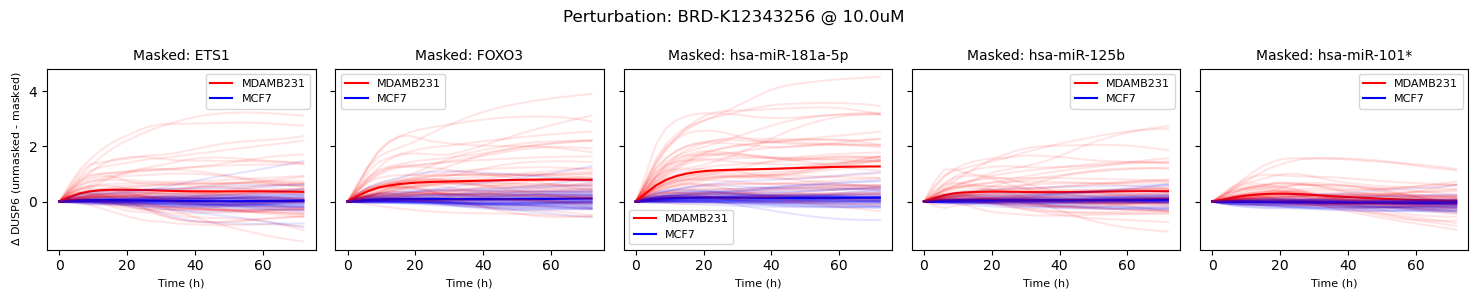

In [124]:
ALPHA = 0.1 
TITLE_FONTSIZE = 10
SUPTITLE_FONTSIZE = 12
AXIS_FONTSIZE = 8
f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 3), sharey=True)

plt.suptitle(f'Perturbation: {drug} @ {dose}uM', fontsize=SUPTITLE_FONTSIZE)
for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 

    diffs1 = diffs_dict[remove_name]['diffs1']
    diffs2 = diffs_dict[remove_name]['diffs2']

    ax.set_title(f'Masked: {remove_name.split("__")[1]}', fontsize=TITLE_FONTSIZE)
    ax.plot(t, diffs1.mean(dim=0).detach().cpu().numpy(), 'r-', label=f'{cell1}')
    ax.plot(t, diffs2.mean(dim=0).detach().cpu().numpy(), 'b-', label=f'{cell2}')

    for i in range(diffs1.shape[0]):
        ax.plot(t, diffs1[i, :].detach().cpu().numpy(), 'r-', alpha=ALPHA)
        ax.plot(t, diffs2[i, :].detach().cpu().numpy(), 'b-', alpha=ALPHA)

    ax.set_xlabel('Time (h)', fontsize=AXIS_FONTSIZE)
    
    if jj == 0: 
        ax.set_ylabel(f'$\Delta$ {target_gene.split("__")[1]} (unmasked - masked)', fontsize=AXIS_FONTSIZE)

    ax.legend(fontsize=AXIS_FONTSIZE) 

plt.tight_layout()
plt.savefig(f'/mnt/c/Users/natha/Documents/lincs_manu_figures/trametinib_mapk_diff_masked_{target_gene}.png', dpi=300)
plt.show() 

# Number of paths in subgraph 

1. Count the total number of paths from drug targets -> target gene 
2. Count the number of paths from drug targets -> target gene that are contained within the subgraph 
3. report the fraction of paths in subgraph explanation 


In [47]:
data = torch.load(os.path.join(root_gsnn, 'bionetwork/bionetwork.pt'), weights_only=False)

In [48]:
src1,dst1 = data.edge_index_dict['function', 'to', 'function']
src2,dst2 = data.edge_index_dict['input', 'to', 'function']
src3,dst3 = data.edge_index_dict['function', 'to', 'output']

all_edges1 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src1], 'target': np.array(data.node_names_dict['function'])[dst1]})
all_edges2 = pd.DataFrame({'source': np.array(data.node_names_dict['input'])[src2], 'target': np.array(data.node_names_dict['function'])[dst2]})
all_edges3 = pd.DataFrame({'source': np.array(data.node_names_dict['function'])[src3], 'target': np.array(data.node_names_dict['output'])[dst3]})

all_edges = pd.concat([all_edges1, all_edges2, all_edges3])
G_full = nx.from_pandas_edgelist(all_edges, source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_full))
print('# edges', len(G_full.edges()))


# nodes 6896
# edges 101423


In [49]:
G_subgraph = nx.from_pandas_edgelist(cres_agg.reset_index()[lambda x: x.prob_gsnn_score > 0.5], source='source', target='target', create_using=nx.DiGraph)

print('# nodes', len(G_subgraph))
print('# edges', len(G_subgraph.edges()))


# nodes 288
# edges 635


In [50]:
root_genes = 'DRUG__BRD-K12343256'
leaf_genes = 'GENE__DUSP6'
depth = 6

In [51]:
all_paths = list(nx.all_simple_edge_paths(G_full, source=root_genes, target=leaf_genes, cutoff=depth))
print('# all paths', len(all_paths))
subgraph_paths = list(nx.all_simple_edge_paths(G_subgraph, source=root_genes, target=leaf_genes, cutoff=depth))
print('# subgraph paths', len(subgraph_paths))

# all paths 175
# subgraph paths 71


In [52]:
print(f'Fraction of paths in subgraph -> {len(subgraph_paths) / len(all_paths):.2f} [{len(subgraph_paths)} / {len(all_paths)}]')
print() 

print('Fraction of edges in subgraph (by length): ') 

path_lengths_subgraph = [len(p) for p in subgraph_paths] 
path_lengths_full = [len(p) for p in all_paths] 

for i in range(4, depth+1):
    n_paths_subgraph = np.sum([p == i for p in path_lengths_subgraph])
    n_paths_full = np.sum([p == i for p in path_lengths_full])
    print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


Fraction of paths in subgraph -> 0.41 [71 / 175]

Fraction of edges in subgraph (by length): 
	Fraction of paths of length 4 -> nan [0 / 0]
	Fraction of paths of length 5 -> 1.00 [9 / 9]
	Fraction of paths of length 6 -> 0.37 [62 / 166]


/tmp/ipykernel_15009/3546800955.py:12: RuntimeWarning: invalid value encountered in scalar divide
  print(f'\tFraction of paths of length {i} -> {n_paths_subgraph / n_paths_full:.2f} [{n_paths_subgraph} / {n_paths_full}]')


In [53]:
cres_agg.head() 

mean_gsnn_score  std_gsnn_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.999745        0.000715   
                    PROTEIN__MAP2K2         0.975754        0.137902   
GENE__ABL1          RNA__ABL1               0.464755        0.471927   
GENE__ADAM10        RNA__ADAM10             0.181358        0.339273   
GENE__ADGRG1        RNA__ADGRG1             0.043628        0.127330   

                                     prob_gsnn_score  mean_ig_score  \
source              target                                            
DRUG__BRD-K12343256 PROTEIN__MAP2K1         0.980769       0.174134   
                    PROTEIN__MAP2K2         0.961538       0.057590   
GENE__ABL1          RNA__ABL1               0.423077       0.008059   
GENE__ADAM10        RNA__ADAM10             0.153846      -0.000798   
GENE__ADGRG1        RNA__ADGRG1             0.019231       0.000161   

                                     std_ig_score  prob_pos_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.131353           0.961538   
                    PROTEIN__MAP2K2      0.067968           0.884615   
GENE__ABL1          RNA__ABL1            0.040234           0.365385   
GENE__ADAM10        RNA__ADAM10          0.007720           0.096154   
GENE__ADGRG1        RNA__ADGRG1          0.001118           0.057692   

                                     prob_neg_ig_score  mean_oc_score  \
source              target                                              
DRUG__BRD-K12343256 PROTEIN__MAP2K1           0.037736       1.438209   
                    PROTEIN__MAP2K2           0.094340       0.534619   
GENE__ABL1          RNA__ABL1                 0.094340       0.068862   
GENE__ADAM10        RNA__ADAM10               0.094340      -0.002655   
GENE__ADGRG1        RNA__ADGRG1               0.000000       0.000095   

                                     std_oc_score  prob_pos_oc_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1      0.937871           0.980769   
                    PROTEIN__MAP2K2      0.716407           0.865385   
GENE__ABL1          RNA__ABL1            0.183958           0.365385   
GENE__ADAM10        RNA__ADAM10          0.015912           0.076923   
GENE__ADGRG1        RNA__ADGRG1          0.000659           0.057692   

                                     prob_neg_oc_score  abs_ig_score  \
source              target                                             
DRUG__BRD-K12343256 PROTEIN__MAP2K1           0.018868      0.174134   
                    PROTEIN__MAP2K2           0.113208      0.057590   
GENE__ABL1          RNA__ABL1                 0.094340      0.008059   
GENE__ADAM10        RNA__ADAM10               0.113208      0.000798   
GENE__ADGRG1        RNA__ADGRG1               0.000000      0.000161   

                                     abs_oc_score  
source              target                         
DRUG__BRD-K12343256 PROTEIN__MAP2K1      1.438209  
                    PROTEIN__MAP2K2      0.534619  
GENE__ABL1          RNA__ABL1            0.068862  
GENE__ADAM10        RNA__ADAM10          0.002655  
GENE__ADGRG1        RNA__ADGRG1          0.000095

# Centrality of miRNAs 

In [54]:
full_centrality = nx.betweenness_centrality(G_full) 

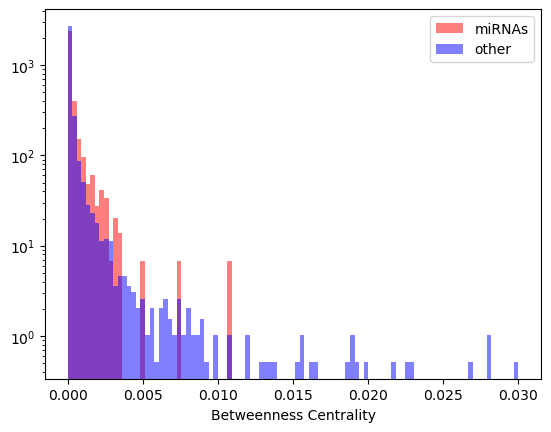

In [55]:

mirna_centralities = {k: v for k, v in full_centrality.items() if k.startswith('RNA__hsa-miR-')}
other_centralities = {k: v for k, v in full_centrality.items() if not k.startswith('RNA__hsa-miR-')}

binss = np.linspace(0,0.03, 100)

plt.figure() 
plt.hist(list(mirna_centralities.values()), bins=binss, label='miRNAs', color='r', alpha=0.5, density=True)
plt.hist(list(other_centralities.values()), bins=binss, label='other', color='b', alpha=0.5, density=True)
plt.yscale('log')
plt.legend()
plt.xlabel('Betweenness Centrality')
plt.show() 

# CELL1 explanation

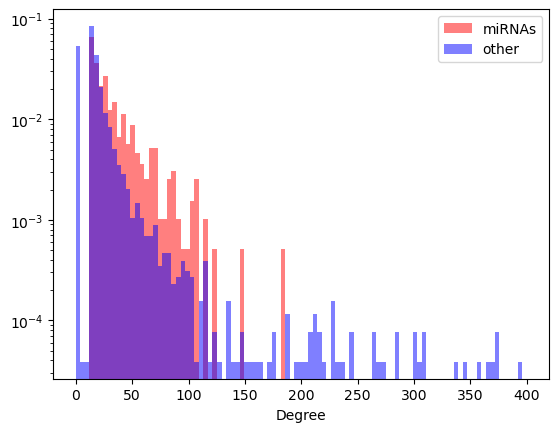

In [56]:
full_degrees = dict(G_full.degree()) 

mirna_degrees = {k: v for k, v in full_degrees.items() if k.startswith('RNA__hsa-miR-')}
other_degrees = {k: v for k, v in full_degrees.items() if not k.startswith('RNA__hsa-miR-')}

binss = np.linspace(0, 400, 100)

plt.figure() 
plt.hist(list(mirna_degrees.values()), bins=binss, label='miRNAs', color='r', alpha=0.5, density=True)
plt.hist(list(other_degrees.values()), bins=binss, label='other', color='b', alpha=0.5, density=True)
plt.yscale('log')
plt.legend()
plt.xlabel('Degree')
plt.show() 


# GSEA 

In [57]:
G = nx.from_pandas_edgelist(cres_agg[lambda x: x.prob_gsnn_score > 0.5].reset_index(), source='source', target='target', create_using=nx.DiGraph)
G_all = nx.from_pandas_edgelist(cres_agg.reset_index(), source='source', target='target', create_using=nx.DiGraph)
gene_list = [x.split('__')[1] for x in G.nodes()]
background = [x.split('__')[1] for x in G_all.nodes()]

enr2 = gp.enrichr(gene_list, 'Reactome_2022', background=background, outdir=None)

enr2.res2d.sort_values(by='Adjusted P-value', ascending=True).head(40)[['Term', 'Adjusted P-value']]

,Term,Adjusted P-value
0,Generic Transcription Pathway R-HSA-212436,3.209230e-20
1,RNA Polymerase II Transcription R-HSA-73857,1.051334e-19
2,Gene Expression (Transcription) R-HSA-74160,1.556254e-19
3,Cellular Senescence R-HSA-2559583,1.239661e-11
4,Developmental Biology R-HSA-1266738,1.155241e-10
5,Transcriptional Regulation Of Granulopoiesis R...,1.027382e-09
6,Cellular Responses To Stress R-HSA-2262752,6.740380e-09
7,Cellular Responses To Stimuli R-HSA-8953897,8.186342e-09
8,Regulation Of TP53 Activity R-HSA-5633007,1.038663e-08
9,Transcriptional Regulation By TP53 R-HSA-3700989,1.677750e-08
